# Customer Churn Dynamics: Training Phase

## Objective
This notebook continues from the EDA phase and focuses on model training, evaluation, and customer segmentation for the Telco Customer Churn dataset.

The goals of this notebook are to:
- prepare the cleaned dataset for machine learning
- train multiple classification models to predict churn
- compare model performance using standard metrics
- identify important predictive features

- apply K-Means clustering to discover customer segments


## Model Training and Predictive Analysis

This section prepares the cleaned dataset for machine learning, trains multiple classification models, and evaluates their ability to predict customer churn. The selected models are Logistic Regression, Decision Tree, and Random Forest. In addition, K-Means clustering is used to identify customer segments and compare churn behavior across groups.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


## Dataset Loading

This section loads the Telco Customer Churn dataset from the zip file and confirms that the file has been read correctly.


In [2]:
zip_path = "archive.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files in zip:", z.namelist())
    with z.open("WA_Fn-UseC_-Telco-Customer-Churn.csv") as f:
        df = pd.read_csv(f)

df.head()


Files in zip: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

The `TotalCharges` column is converted to numeric form. Any rows that become missing after conversion are removed before modeling.


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

rows_before = df.shape[0]
df = df.dropna()
rows_after = df.shape[0]

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", rows_after)
print("Rows removed:", rows_before - rows_after)
print("Shape after dropping missing values:", df.shape)


Rows before cleaning: 7043
Rows after cleaning: 7032
Rows removed: 11
Shape after dropping missing values: (7032, 21)


## Modeling Preparation

The cleaned dataset is copied into a separate dataframe for training purposes. The target variable is `Churn`, and categorical variables are converted into numeric form before training.


In [4]:
model_df = df.copy()
model_df = model_df.drop(columns=['customerID'])
model_df['Churn'] = model_df['Churn'].map({'No': 0, 'Yes': 1})

model_df_encoded = pd.get_dummies(model_df, drop_first=True)
model_df_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## Encoding Notes

Categorical features were converted into numeric form using one-hot encoding. The `drop_first=True` setting helps reduce redundancy and avoids unnecessary duplicate columns.


In [5]:
X = model_df_encoded.drop(columns=['Churn'])
y = model_df_encoded['Churn']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (7032, 30)
Target shape: (7032,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (5625, 30)
Testing set shape: (1407, 30)


## Train-Test Split

The dataset is split into training and testing sets using an 80/20 ratio. Stratified sampling is used to preserve the churn class distribution in both sets.


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Feature Scaling

Feature scaling is applied using `StandardScaler` for models that are sensitive to feature magnitudes, especially Logistic Regression and K-Means clustering. Tree-based models do not require scaling.


## Logistic Regression


In [9]:
log_model = LogisticRegression(max_iter=200, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression Results")
print("Accuracy:", round(log_accuracy, 4))
print("Precision:", round(log_precision, 4))
print("Recall:", round(log_recall, 4))
print("F1 Score:", round(log_f1, 4))


Logistic Regression Results
Accuracy: 0.8038
Precision: 0.6476
Recall: 0.5749
F1 Score: 0.6091


In [10]:
print("Confusion Matrix - Logistic Regression")
print(confusion_matrix(y_test, y_pred_log))


Confusion Matrix - Logistic Regression
[[916 117]
 [159 215]]


In [11]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_log))


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## Logistic Regression Results

Accuracy: 0.8038  
Precision: 0.6476  
Recall: 0.5749  
F1 Score: 0.6091  

Comments:
Logistic Regression shows strong overall performance with an accuracy of 80.38%. 
Its precision of 64.76% indicates that when the model predicts a customer will churn, 
it is correct a majority of the time. The recall of 57.49% shows that it is able to 
identify over half of the actual churn cases. 

This suggests the model is reasonably effective at detecting churn while maintaining 
a balance between missing churn cases and avoiding false positives. The F1 score of 
0.6091 reflects this balance between precision and recall.

## Decision Tree


In [12]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("Accuracy:", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall:", round(tree_recall, 4))
print("F1 Score:", round(tree_f1, 4))


Decision Tree Results
Accuracy: 0.7783
Precision: 0.5807
Recall: 0.5963
F1 Score: 0.5884


In [13]:
print("Confusion Matrix - Decision Tree")
print(confusion_matrix(y_test, y_pred_tree))


Confusion Matrix - Decision Tree
[[872 161]
 [151 223]]


In [14]:
print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree))


Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



## Decision Tree Results

Accuracy: 0.7783  
Precision: 0.5807  
Recall: 0.5963  
F1 Score: 0.5884  


Comments:
The Decision Tree model achieves an accuracy of 77.83%. Its recall of 59.63% indicates 
that it captures slightly more churn cases than it misses, making it relatively effective 
at detecting customers who leave. However, its precision of 58.07% shows that a larger 
portion of its churn predictions are incorrect compared to other models.

This suggests that while the model is reasonably sensitive to churn, it also produces 
more false positives. The F1 score of 0.5884 reflects a moderate balance between 
precision and recall.

## Random Forest


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))


Random Forest Results
Accuracy: 0.7932
Precision: 0.6509
Recall: 0.4786
F1 Score: 0.5516


In [16]:
print("Confusion Matrix - Random Forest")
print(confusion_matrix(y_test, y_pred_rf))


Confusion Matrix - Random Forest
[[937  96]
 [195 179]]


In [17]:
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Random Forest Results

Accuracy: 0.7932  
Precision: 0.6509  
Recall: 0.4786  
F1 Score: 0.5516  


Comments:
Random Forest achieves an accuracy of 79.32% and a precision of 65.09%, indicating that 
its churn predictions are relatively reliable when it does identify a customer as likely 
to churn. However, its recall of 47.86% shows that it misses more than half of the actual 
churn cases.

This means the model is more conservative in predicting churn and tends to overlook many 
at-risk customers. The lower F1 score of 0.5516 reflects this imbalance between precision 
and recall.


## Model Comparison


In [29]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_accuracy, tree_accuracy, rf_accuracy],
    'Precision': [log_precision, tree_precision, rf_precision],
    'Recall': [log_recall, tree_recall, rf_recall],
    'F1 Score': [log_f1, tree_f1, rf_f1]
})

results_df = results_df.round(4)
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091
1,Decision Tree,0.7783,0.5807,0.5963,0.5884
2,Random Forest,0.7932,0.6509,0.4786,0.5516


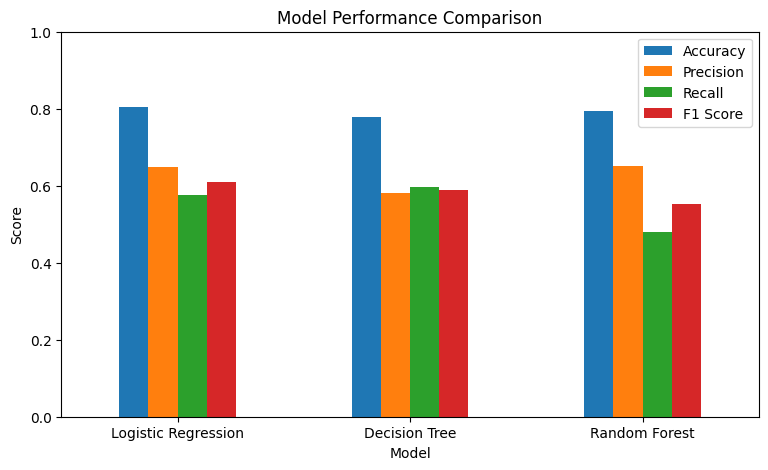

In [30]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()


## Model Comparison Notes

Best model based on accuracy:
Logistic Regression

Best model based on F1 score:
Logistic Regression

Most balanced model:
Logistic Regression

Comments:
Logistic Regression performs best overall due to its balanced performance across all 
evaluation metrics. While Random Forest has slightly higher precision, its low recall 
makes it less suitable for churn prediction. Decision Tree provides moderate results 
but lacks consistency.


## Feature Importance Analysis


In [20]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
feature_importance.head(10)


,Feature,Importance
1,tenure,0.201479
3,TotalCharges,0.140288
2,MonthlyCharges,0.097841
10,InternetService_Fiber optic,0.083823
25,Contract_Two year,0.075743
28,PaymentMethod_Electronic check,0.065982
13,OnlineSecurity_Yes,0.045141
24,Contract_One year,0.037089
19,TechSupport_Yes,0.026770
16,DeviceProtection_No internet service,0.022817


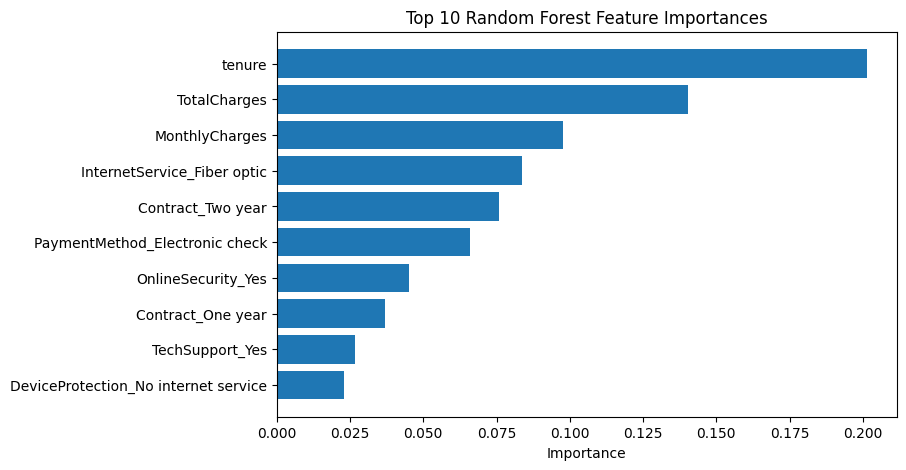

In [21]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.show()


## Feature Importance Notes

Most important feature:
Tenure

Other important features:
TotalCharges, MonthlyCharges, InternetService_Fiber optic, Contract type

Do these align with EDA findings?
Yes, these results align with the EDA phase, where customers with shorter tenure and 
higher monthly charges were more likely to churn.

Comments:
Customers with shorter tenure are more likely to churn, indicating early-stage 
instability. Higher monthly charges also contribute to churn risk. Contract type 
plays a significant role, with long-term contracts reducing churn likelihood.


## K-Means Clustering

K-Means clustering is used to identify customer segments based on a small set of meaningful numerical features: tenure, MonthlyCharges, TotalCharges, and SeniorCitizen.


In [22]:
cluster_features = model_df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()

cluster_scaler = StandardScaler()
cluster_data_scaled = cluster_scaler.fit_transform(cluster_features)


In [23]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
model_df['Cluster'] = kmeans.fit_predict(cluster_data_scaled)


In [24]:
model_df['Cluster'].value_counts().sort_index()


Cluster
0    1875
1    4015
2    1142
Name: count, dtype: int64

In [25]:
cluster_churn = pd.crosstab(model_df['Cluster'], model_df['Churn'], normalize='index') * 100
cluster_churn.round(2)


Churn,0,1
Cluster,,
0,85.55,14.45
1,72.05,27.95
2,58.32,41.68


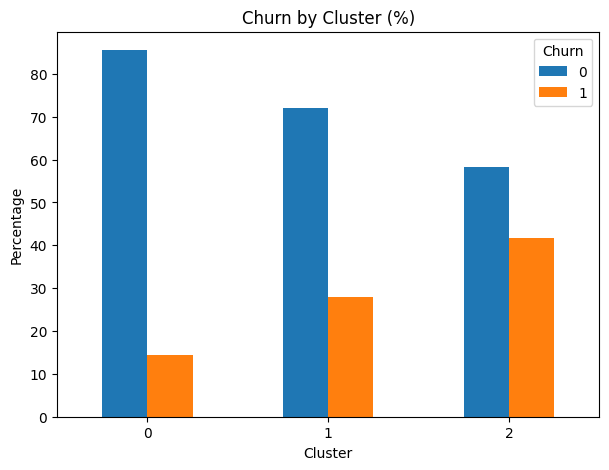

In [26]:
cluster_churn.plot(kind='bar', figsize=(7,5))
plt.title('Churn by Cluster (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()


In [27]:
cluster_summary = model_df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].mean().round(2)
cluster_summary


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
Cluster,,,,
0,57.24,88.63,5056.32,0.0
1,20.58,49.40,838.36,0.0
2,33.30,79.82,2810.47,1.0


## K-Means Clustering Results

Number of clusters used:
3

Cluster with highest churn:
Cluster 2

Cluster with lowest churn:
Cluster 0

General characteristics of Cluster 0:
Customers with long tenure, high total charges, and low churn rate. These are likely 
loyal, long-term customers.

General characteristics of Cluster 1:
Customers with shorter tenure and lower total charges. This group represents newer 
customers with moderate churn risk.

General characteristics of Cluster 2:
Customers with medium tenure, high monthly charges, and the highest churn rate. 
This group is the most at-risk segment.

Comments:
Clustering reveals clear customer segments with different churn behaviors. High-risk 
customers tend to have higher monthly costs and shorter or unstable service duration.

## Final Summary

Multiple models were trained to predict customer churn, with Logistic Regression 
providing the best overall performance due to its balance of accuracy and recall. 
Feature importance analysis highlights tenure and billing-related variables as key 
drivers of churn. K-Means clustering further reveals distinct customer segments, 
with one group showing significantly higher churn risk. These results support both 
predictive modeling and customer segmentation as effective approaches for churn analysis.


In [28]:
# Final quick peek at the modeling dataset
model_df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1


In [31]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']